In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader, TensorDataset
from torchvision import transforms, datasets, models
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

In [3]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super(MNISTCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(64, 32)

        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        
        x = self.gap(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [4]:
model = MNISTCNN()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total Trainable Parameters: {total_params}')
assert total_params <= 50000

Total Trainable Parameters: 25706


In [5]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1387,), (0.3081,))
])

full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=mnist_transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=mnist_transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train set size: {len(train_dataset)}")
print(f"Val set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


Train set size: 48000
Val set size: 12000
Test set size: 10000


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNISTCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"| Train Acc: {train_acc:>5.2f}% | Val Acc: {val_acc:>5.2f}% "
          f"| Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch [1/10] | Train Acc: 62.52% | Val Acc: 88.72% | Train Loss: 1.0570 | Val Loss: 0.3832
Epoch [2/10] | Train Acc: 90.76% | Val Acc: 91.89% | Train Loss: 0.3054 | Val Loss: 0.2662
Epoch [3/10] | Train Acc: 93.52% | Val Acc: 94.48% | Train Loss: 0.2138 | Val Loss: 0.1826
Epoch [4/10] | Train Acc: 94.82% | Val Acc: 94.76% | Train Loss: 0.1716 | Val Loss: 0.1699
Epoch [5/10] | Train Acc: 95.73% | Val Acc: 95.92% | Train Loss: 0.1423 | Val Loss: 0.1316
Epoch [6/10] | Train Acc: 96.33% | Val Acc: 95.13% | Train Loss: 0.1205 | Val Loss: 0.1512
Epoch [7/10] | Train Acc: 96.91% | Val Acc: 97.27% | Train Loss: 0.1027 | Val Loss: 0.0863
Epoch [8/10] | Train Acc: 97.28% | Val Acc: 96.88% | Train Loss: 0.0887 | Val Loss: 0.0958
Epoch [9/10] | Train Acc: 97.45% | Val Acc: 97.14% | Train Loss: 0.0799 | Val Loss: 0.0869
Epoch [10/10] | Train Acc: 97.86% | Val Acc: 97.68% | Train Loss: 0.0686 | Val Loss: 0.0750


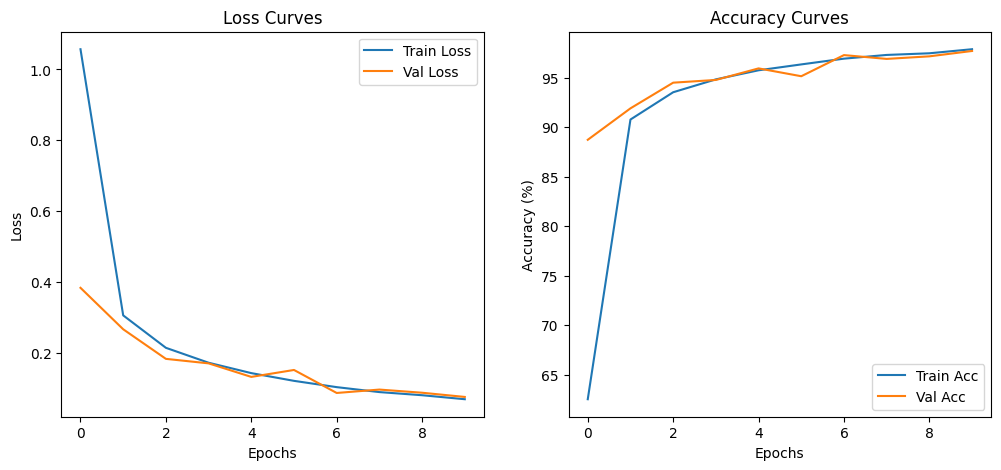

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

In [8]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

final_test_acc = 100. * test_correct / test_total

print("-" * 30)
print(f"Final Evaluation on Test Set")
print(f"Total Images Tested: {test_total}")
print(f"Correct Predictions: {test_correct}")
print(f"Final Test Accuracy: {final_test_acc:.2f}%")
print("-" * 30)

------------------------------
Final Evaluation on Test Set
Total Images Tested: 10000
Correct Predictions: 9792
Final Test Accuracy: 97.92%
------------------------------


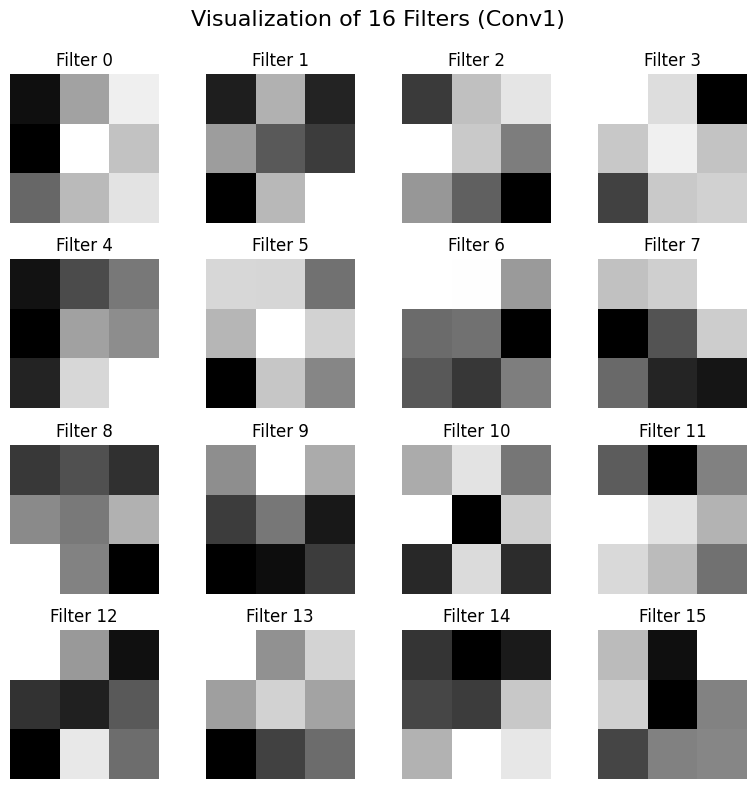

In [9]:
weights = model.conv1.weight.detach().cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Visualization of 16 Filters (Conv1)', fontsize=16)

for i, ax in enumerate(axes.flat):
    filt = weights[i, 0, :, :]
    
    filt_min, filt_max = filt.min(), filt.max()
    filt = (filt - filt_min) / (filt_max - filt_min + 1e-8)
    
    ax.imshow(filt, cmap='gray')
    ax.set_title(f'Filter {i}')
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [10]:
class CMNISTCNN(nn.Module):
    def __init__(self):
        super(CMNISTCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(64, 32)

        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        
        x = self.gap(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [18]:
model = CMNISTCNN()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total Trainable Parameters: {total_params}')
assert total_params <= 50000

Total Trainable Parameters: 25994


In [14]:
CMNIST_DIR = 'data/cmnist/'

data_train = torch.load(CMNIST_DIR + 'train_biased.pt')
data_test_b = torch.load(CMNIST_DIR + 'test_biased.pt')
data_test_ub = torch.load(CMNIST_DIR + 'test_unbiased.pt')

print(type(data_train))

print(f"Type: {type(data_train)}")
print(f"Length: {len(data_train)}")
print(f"Shape of first element: {data_train[0].shape}")
print(f"Shape of second element: {data_train[1].shape}")

<class 'tuple'>
Type: <class 'tuple'>
Length: 2
Shape of first element: torch.Size([60000, 3, 28, 28])
Shape of second element: torch.Size([60000])


In [20]:
train_images, train_labels = data_train
test_b_images, test_b_labels = data_test_b
test_ub_images, test_ub_labels = data_test_ub

def create_cmnist_loader(images, labels, batch_size=128, shuffle=False):
    images = images.float()
    if images.max() > 1.0:
        images /= 255.0
    
    labels = labels.long()
    
    dataset = TensorDataset(images, labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = create_cmnist_loader(train_images, train_labels, shuffle=True)
test_b_loader = create_cmnist_loader(test_b_images, test_b_labels)
test_ub_loader = create_cmnist_loader(test_ub_images, test_ub_labels)

print("CMNIST Loaders Ready.")

CMNIST Loaders Ready.


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CMNISTCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = {
    'train_loss': [],
    'train_acc': []
}

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
            
    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"| Train Acc: {train_acc:>5.2f}% "
          f"| Train Loss: {avg_train_loss:.4f}")

Epoch [1/10] | Train Acc: 85.60% | Train Loss: 0.6139
Epoch [2/10] | Train Acc: 94.98% | Train Loss: 0.3019
Epoch [3/10] | Train Acc: 95.04% | Train Loss: 0.2707
Epoch [4/10] | Train Acc: 95.15% | Train Loss: 0.2403
Epoch [5/10] | Train Acc: 95.38% | Train Loss: 0.2070
Epoch [6/10] | Train Acc: 95.71% | Train Loss: 0.1757
Epoch [7/10] | Train Acc: 96.12% | Train Loss: 0.1498
Epoch [8/10] | Train Acc: 96.42% | Train Loss: 0.1326
Epoch [9/10] | Train Acc: 96.73% | Train Loss: 0.1158
Epoch [10/10] | Train Acc: 97.01% | Train Loss: 0.1043


In [23]:
def evaluate_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100. * correct / total

acc_biased = evaluate_model(model, test_b_loader, device)
acc_unbiased = evaluate_model(model, test_ub_loader, device)

print("-" * 30)
print(f"CMNIST Evaluation Results")
print(f"Biased Test Accuracy:   {acc_biased:.2f}%")
print(f"Unbiased Test Accuracy: {acc_unbiased:.2f}%")
print("-" * 30)

------------------------------
CMNIST Evaluation Results
Biased Test Accuracy:   97.16%
Unbiased Test Accuracy: 47.54%
------------------------------


In [25]:
stl10_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
])

train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=stl10_transform)
test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=stl10_transform)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"STL-10 Training samples: {len(train_dataset)}")
print(f"STL-10 Test samples: {len(test_dataset)}")

100.0%


STL-10 Training samples: 5000
STL-10 Test samples: 8000


In [26]:
STL10_CLASSES = train_dataset.classes

print(f"Number of classes: {len(STL10_CLASSES)}")
print(f"Class names: {STL10_CLASSES}")

Number of classes: 10
Class names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [30]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/faaiz/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Total parameters: 11181642
Trainable parameters: 5130


In [31]:
epochs = 5

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
            
    print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {100.*train_correct/train_total:.2f}%")

model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\nFinal STL-10 Test Accuracy (Frozen Backbone): {100.*test_correct/test_total:.2f}%")

Epoch [1/5] | Train Acc: 75.90%
Epoch [2/5] | Train Acc: 92.62%
Epoch [3/5] | Train Acc: 94.08%
Epoch [4/5] | Train Acc: 94.52%
Epoch [5/5] | Train Acc: 95.08%

Final STL-10 Test Accuracy (Frozen Backbone): 94.45%


In [39]:
target_layers = [model.layer4]

cam = GradCAM(model=model, target_layers=target_layers)

def get_gradcam_image(input_tensor, target_category=None):
    # CRITICAL: Input must track gradients for GradCAM to work
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    
    targets = [ClassifierOutputTarget(target_category)] if target_category is not None else None
    
    # Generate the cam
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Undo normalization for display
    img_show = input_tensor.squeeze().cpu().detach().permute(1, 2, 0).numpy()
    img_show = (img_show * np.array([0.2603, 0.2566, 0.2713])) + np.array([0.4467, 0.4398, 0.4066])
    img_show = np.clip(img_show, 0, 1)
    
    visualization = show_cam_on_image(img_show, grayscale_cam, use_rgb=True)
    return visualization

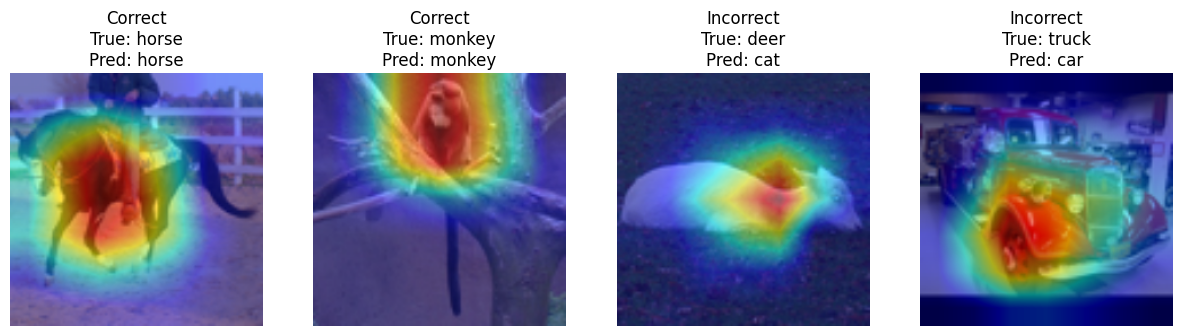

In [40]:
model.eval()
correct_samples = []
incorrect_samples = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        
        for i in range(len(imgs)):
            if preds[i] == lbls[i] and len(correct_samples) < 2:
                correct_samples.append((imgs[i].unsqueeze(0), lbls[i].item(), preds[i].item()))
            elif preds[i] != lbls[i] and len(incorrect_samples) < 2:
                incorrect_samples.append((imgs[i].unsqueeze(0), lbls[i].item(), preds[i].item()))
        
        if len(correct_samples) == 2 and len(incorrect_samples) == 2:
            break

samples = correct_samples + incorrect_samples
titles = ["Correct", "Correct", "Incorrect", "Incorrect"]
classes = test_dataset.classes

plt.figure(figsize=(15, 10))
for i, (img, true_lbl, pred_lbl) in enumerate(samples):
    cam_img = get_gradcam_image(img, target_category=pred_lbl)
    plt.subplot(1, 4, i+1)
    plt.imshow(cam_img)
    plt.title(f"{titles[i]}\nTrue: {classes[true_lbl]}\nPred: {classes[pred_lbl]}")
    plt.axis('off')
plt.show()